Loading data...
Train shape: (630000, 21)
Test shape:  (270000, 20)

--- Target Distribution ---
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64


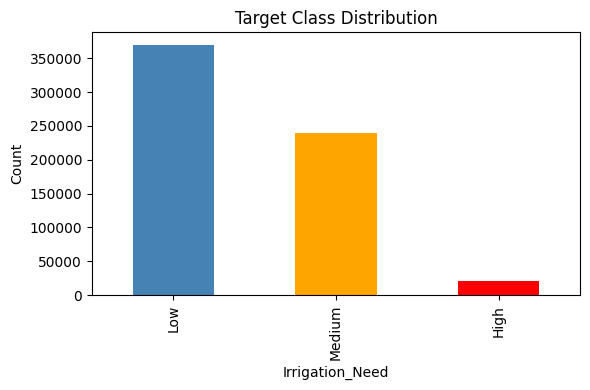

Saved: target_distribution.png

Preprocessing...
Target encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Train set: (504000, 19), Val set: (126000, 19)

Model: Decision Tree
Validation Accuracy: 0.9854
              precision    recall  f1-score   support

        High       0.96      0.92      0.94      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



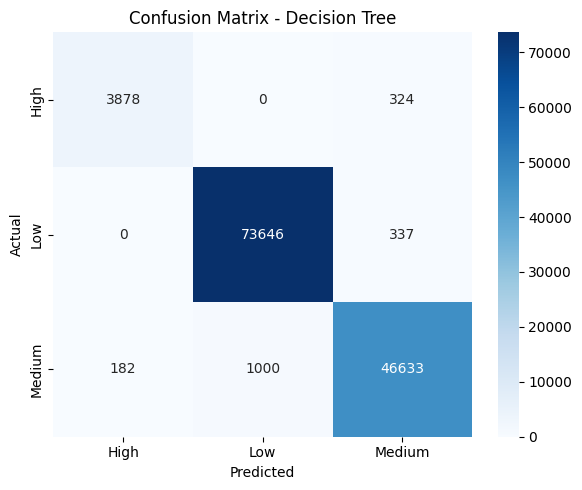

Saved: cm_Decision_Tree.png

Model: Naive Bayes
Validation Accuracy: 0.8276
              precision    recall  f1-score   support

        High       0.72      0.42      0.53      4202
         Low       0.85      0.90      0.88     73983
      Medium       0.79      0.75      0.77     47815

    accuracy                           0.83    126000
   macro avg       0.79      0.69      0.73    126000
weighted avg       0.82      0.83      0.82    126000



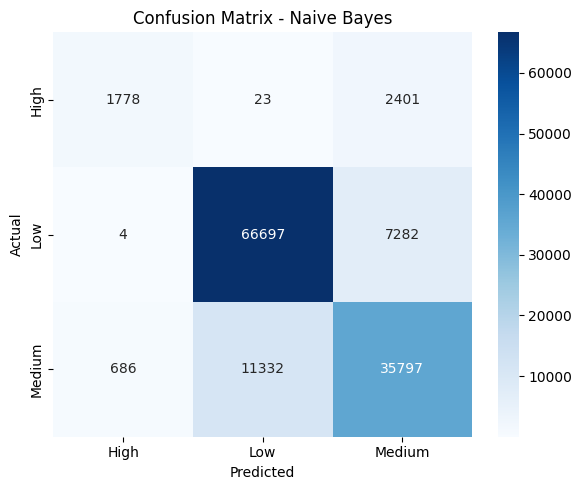

Saved: cm_Naive_Bayes.png

Model: Logistic Regression
Validation Accuracy: 0.7488
              precision    recall  f1-score   support

        High       0.68      0.36      0.47      4202
         Low       0.79      0.84      0.81     73983
      Medium       0.68      0.65      0.66     47815

    accuracy                           0.75    126000
   macro avg       0.72      0.61      0.65    126000
weighted avg       0.75      0.75      0.74    126000



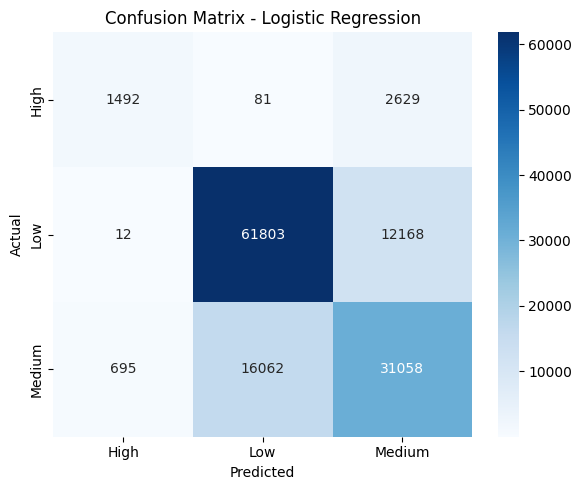

Saved: cm_Logistic_Regression.png

Model: K-Means as Classifier
Validation Accuracy: 0.6867


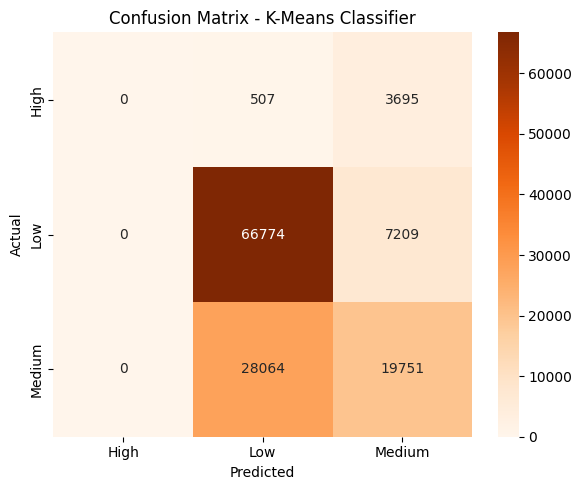

Saved: cm_KMeans_Classifier.png

Model: Random Forest
Validation Accuracy: 0.9859
              precision    recall  f1-score   support

        High       0.97      0.91      0.94      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



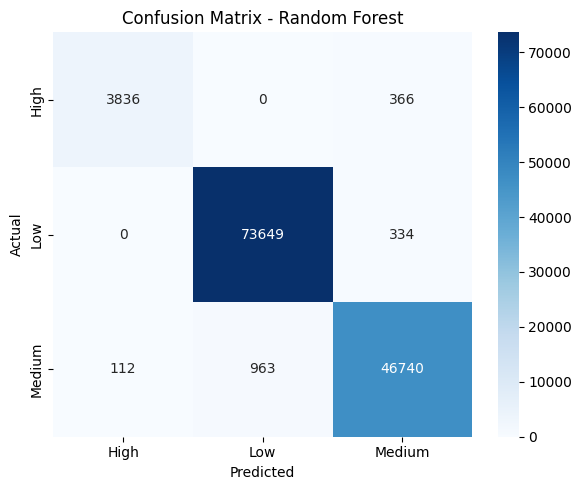

Saved: cm_Random_Forest.png

Cross Validation (K-Fold, k=5)
Decision Tree - K-Fold CV Accuracy: 0.9846 ± 0.0006
Random Forest - K-Fold CV Accuracy: 0.9852 ± 0.0006

LOOCV (on 300-sample subset for speed):
Decision Tree LOOCV Accuracy (300 samples): 0.7633

MODEL COMPARISON SUMMARY
Random Forest             Accuracy: 0.9859
Decision Tree             Accuracy: 0.9854
Naive Bayes               Accuracy: 0.8276
Logistic Regression       Accuracy: 0.7488
K-Means Classifier        Accuracy: 0.6867


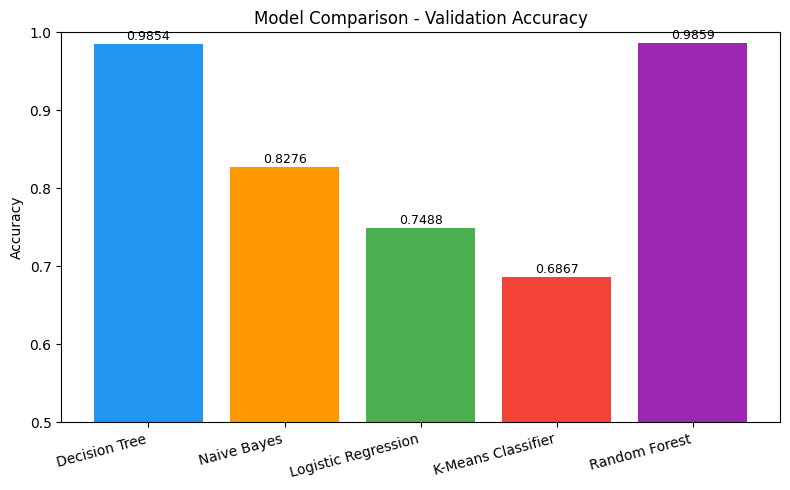

Saved: model_comparison.png

Training FINAL model on full training data...
Submission file saved: submission.csv
Irrigation_Need
Low       159842
Medium    101659
High        8499
Name: count, dtype: int64
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low


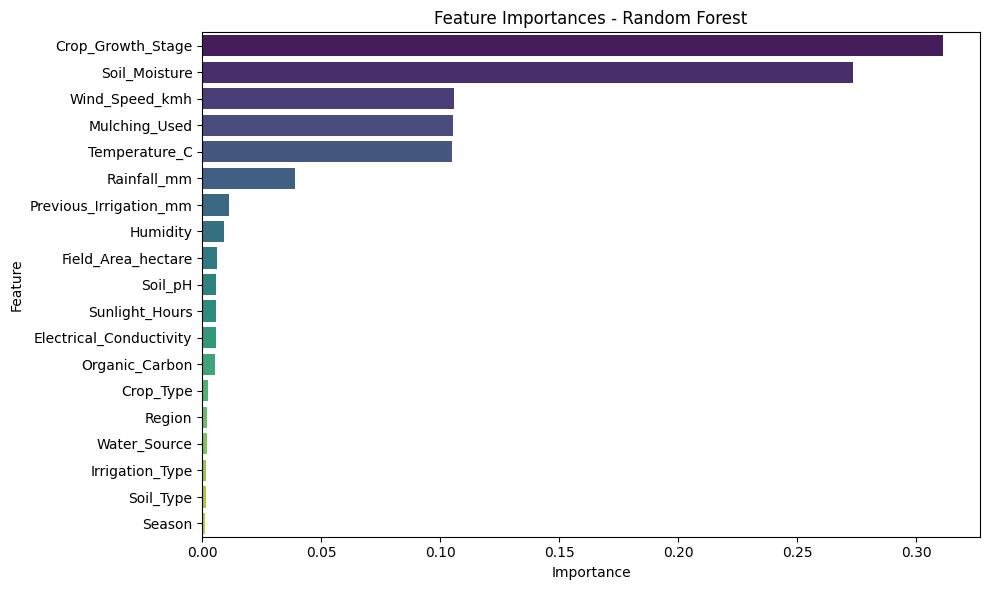

Saved: feature_importance.png

ALL DONE!


In [2]:
# Kaggle Playground Series S6E4 - Predicting Irrigation Need
# Multiclass Classification: Low / Medium / High

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import mode

# 1. LOAD DATA
print("Loading data...")
train = pd.read_csv('/content/train.csv')
test  = pd.read_csv('/content/test.csv')
sample = pd.read_csv('/content/sample_submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

# 2. EDA - Quick look
print("\n--- Target Distribution ---")
print(train['Irrigation_Need'].value_counts())

# Plot target distribution
plt.figure(figsize=(6,4))
train['Irrigation_Need'].value_counts().plot(kind='bar', color=['steelblue','orange','red'])
plt.title('Target Class Distribution')
plt.xlabel('Irrigation_Need')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show()
print("Saved: target_distribution.png")

# 3. PREPROCESSING
print("\nPreprocessing...")

# Categorical columns to encode
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

# Encode categorical features using LabelEncoder
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0)
    le.fit(combined)
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])
    le_dict[col] = le

# Encode target
le_target = LabelEncoder()
train['Irrigation_Need'] = le_target.fit_transform(train['Irrigation_Need'])
# Classes: check mapping
print("Target encoding:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# Features and target
feature_cols = [c for c in train.columns if c not in ['id', 'Irrigation_Need']]
X = train[feature_cols].values
y = train['Irrigation_Need'].values
X_test_final = test[feature_cols].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

# Train/validation split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}, Val set: {X_val.shape}")

# 4. MODEL TRAINING & EVALUATION

results = {}

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    """Train, evaluate, plot confusion matrix."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    acc = accuracy_score(y_v, preds)
    results[name] = acc

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Validation Accuracy: {acc:.4f}")
    print(classification_report(y_v, preds, target_names=le_target.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_v, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_target.classes_,
                yticklabels=le_target.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    fname = f'cm_{name.replace(" ","_")}.png'
    plt.savefig(fname)
    plt.show()
    print(f"Saved: {fname}")
    return model, acc

# --- 4a. Decision Tree ---
dt_model, dt_acc = evaluate_model(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=10, random_state=42),
    X_train, y_train, X_val, y_val
)

# --- 4b. Naive Bayes ---
nb_model, nb_acc = evaluate_model(
    "Naive Bayes",
    GaussianNB(),
    X_train, y_train, X_val, y_val
)

# --- 4c. Logistic Regression ---
lr_model, lr_acc = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
    X_train, y_train, X_val, y_val
)

# --- 4d. K-Means as Classifier ---
print(f"\n{'='*50}")
print("Model: K-Means as Classifier")
n_classes = len(np.unique(y))
kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
kmeans.fit(X_train)

# Map each cluster to the most common true label in that cluster
cluster_label_map = {}
for cluster_id in range(n_classes):
    mask = (kmeans.labels_ == cluster_id)
    if mask.sum() > 0:
        cluster_label_map[cluster_id] = mode(y_train[mask], keepdims=True)[0][0]

val_clusters = kmeans.predict(X_val)
kmeans_preds = np.array([cluster_label_map[c] for c in val_clusters])
km_acc = accuracy_score(y_val, kmeans_preds)
results["K-Means Classifier"] = km_acc
print(f"Validation Accuracy: {km_acc:.4f}")

cm = confusion_matrix(y_val, kmeans_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix - K-Means Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('cm_KMeans_Classifier.png')
plt.show()
print("Saved: cm_KMeans_Classifier.png")

# --- 4e. Random Forest (Advanced / Best Model) ---
rf_model, rf_acc = evaluate_model(
    "Random Forest",
    RandomForestClassifier(n_estimators=200, max_depth=20,
                           random_state=42, n_jobs=-1),
    X_train, y_train, X_val, y_val
)

# 5. CROSS VALIDATION
print(f"\n{'='*50}")
print("Cross Validation (K-Fold, k=5)")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Run K-Fold on Decision Tree and Random Forest (fast enough)
for name, model in [("Decision Tree", DecisionTreeClassifier(max_depth=10, random_state=42)),
                    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))]:
    scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='accuracy', n_jobs=-1)
    print(f"{name} - K-Fold CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

# LOOCV on a small sample (LOOCV is too slow for 630k rows)
print("\nLOOCV (on 300-sample subset for speed):")
X_small = X_scaled[:300]
y_small = y[:300]
loo = LeaveOneOut()
loo_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=10, random_state=42),
    X_small, y_small, cv=loo
)
print(f"Decision Tree LOOCV Accuracy (300 samples): {loo_scores.mean():.4f}")

# 6. MODEL COMPARISON SUMMARY
print(f"\n{'='*50}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*50}")
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:<25} Accuracy: {acc:.4f}")

# Bar chart
plt.figure(figsize=(8,5))
names = list(results.keys())
accs  = [results[n] for n in names]
bars = plt.bar(names, accs, color=['#2196F3','#FF9800','#4CAF50','#F44336','#9C27B0'])
plt.ylim(0.5, 1.0)
plt.title('Model Comparison - Validation Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=15, ha='right')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()
print("Saved: model_comparison.png")

# 7. FINAL MODEL - TRAIN ON FULL DATA & GENERATE SUBMISSION
print(f"\n{'='*50}")
print("Training FINAL model on full training data...")

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_scaled, y)  # Train on ALL training data

# Predict on test set
test_preds_encoded = final_model.predict(X_test_scaled)
test_preds_labels  = le_target.inverse_transform(test_preds_encoded)

# Creating submission file
submission = sample.copy()
submission['Irrigation_Need'] = test_preds_labels
submission.to_csv('submission.csv', index=False)

print("Submission file saved: submission.csv")
print(submission['Irrigation_Need'].value_counts())
print(submission.head())

# 8. FEATURE IMPORTANCE (from Random Forest)
importances = final_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("Saved: feature_importance.png")

print(f"\n{'='*50}")
print("ALL DONE!")
print(f"{'='*50}")